# Interpretable Multimodal Machine Learning for Early Risk Prediction from Temporal Healthcare Data
## Early sepsis prediction from open ICU clinical time-series data

This notebook implements a reproducible machine learning pipeline for early sepsis prediction using open ICU time-series data from the PhysioNet/Computing in Cardiology Challenge 2019.

We compare three feature settings:
1. Static-only
2. Temporal-only
3. Multimodal (static + temporal)

We evaluate predictive performance using AUC, AUPRC, F1, precision, and recall, and we interpret the best-performing model using feature importance and SHAP-style analysis if time allows.

In [1]:
# !pip install numpy pandas matplotlib scikit-learn xgboost shap

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

### Paths and file discovery

In [3]:
DATA_DIR_A = "physionet.org/files/challenge-2019/1.0.0/training/training_setA"
DATA_DIR_B = "physionet.org/files/challenge-2019/1.0.0/training/training_setB"

files_A = sorted(glob.glob(os.path.join(DATA_DIR_A, "*.psv")))
files_B = sorted(glob.glob(os.path.join(DATA_DIR_B, "*.psv")))

patient_files = files_A + files_B

print("Files in set A:", len(files_A))
print("Files in set B:", len(files_B))
print("Total patient files:", len(patient_files))
print("Example file:", patient_files[0] if patient_files else "No files found")

Files in set A: 20320
Files in set B: 4352
Total patient files: 24672
Example file: physionet.org/files/challenge-2019/1.0.0/training/training_setA\p000001.psv


### Inspect one patient file

In [4]:
sample_file = patient_files[0]
df_sample = pd.read_csv(sample_file, sep="|")

print("Shape:", df_sample.shape)
print("Columns:", df_sample.columns.tolist())
df_sample.head()

Shape: (54, 41)
Columns: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


### Visualize one patient

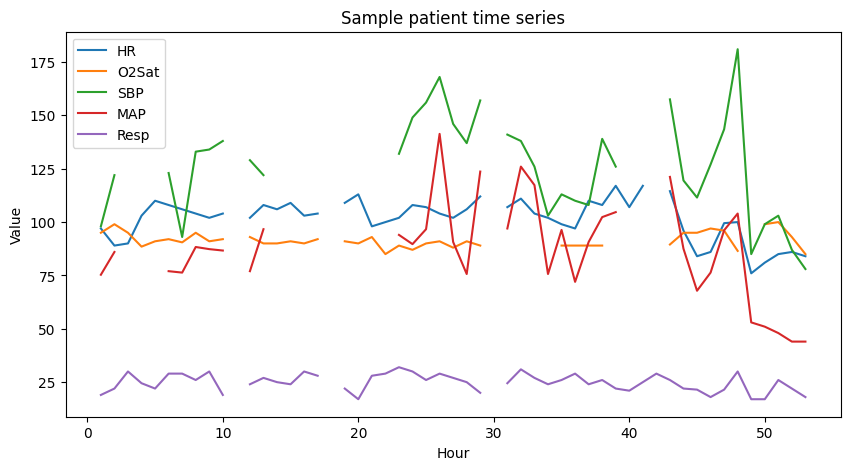

In [5]:
cols_to_plot = ["HR", "O2Sat", "SBP", "MAP", "Resp"]

df_sample[cols_to_plot].plot(figsize=(10, 5))
plt.title("Sample patient time series")
plt.xlabel("Hour")
plt.ylabel("Value")
plt.show()

### Define variables

In [6]:
static_cols = ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime"]

temporal_cols = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2",
    "Glucose", "Lactate", "WBC", "Creatinine", "Platelets"
]

target_col = "SepsisLabel"

# ------------------ Decide prediction window ------------------ #
EARLY_HOURS = 12

### Patient-level feature construction

Each patient file contains hourly ICU measurements. To obtain a fixed-size representation suitable for classical machine learning models, we summarize the first 12 hours of each patient record.

We construct:
- Static features from demographic and admission variables
- Temporal summary features from selected physiological and laboratory variables using:
  - mean
  - standard deviation
  - minimum
  - maximum
  - last observed value

This produces a patient-level tabular representation for static, temporal, and multimodal modeling.

In [7]:
def summarize_patient(file_path, early_hours=12):
    df = pd.read_csv(file_path, sep="|")
    df = df.iloc[:early_hours].copy()

    row = {}
    row["patient_id"] = os.path.basename(file_path).replace(".psv", "")

    # Static features
    for col in static_cols:
        if col in df.columns:
            non_null = df[col].dropna()
            row[col] = non_null.iloc[0] if len(non_null) > 0 else np.nan
        else:
            row[col] = np.nan

    # Temporal summary features
    for col in temporal_cols:
        if col in df.columns:
            values = df[col]

            row[f"{col}_mean"] = values.mean()
            row[f"{col}_std"] = values.std()
            row[f"{col}_min"] = values.min()
            row[f"{col}_max"] = values.max()

            non_null = values.dropna()
            row[f"{col}_last"] = non_null.iloc[-1] if len(non_null) > 0 else np.nan
        else:
            row[f"{col}_mean"] = np.nan
            row[f"{col}_std"] = np.nan
            row[f"{col}_min"] = np.nan
            row[f"{col}_max"] = np.nan
            row[f"{col}_last"] = np.nan

    # Patient-level label:
    # 1 if sepsis appears at any point in the early window, else 0
    if target_col in df.columns:
        row["label"] = int(df[target_col].max())
    else:
        row["label"] = 0

    return row

### Build dataset from many patients

In [8]:
small_patient_files = patient_files[:10000]
# Once this works, change 500 to 2000, then maybe all patients.

rows = [summarize_patient(fp, early_hours=EARLY_HOURS) for fp in small_patient_files]
data = pd.DataFrame(rows)

print("Dataset shape:", data.shape)
data.head()

# ---------------------------- Check labels and missingness ---------------------------- #

print("Label counts:")
print(data["label"].value_counts(dropna=False))
print("\nPositive rate:")
print(data["label"].mean())

missing_summary = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_fraction": data.isna().mean()
}).sort_values("missing_fraction", ascending=False)

missing_summary.head(30)

Dataset shape: (10000, 72)
Label counts:
label
0    9716
1     284
Name: count, dtype: int64

Positive rate:
0.0284


,missing_count,missing_fraction
EtCO2_last,10000,1.0000
EtCO2_std,10000,1.0000
EtCO2_min,10000,1.0000
EtCO2_mean,10000,1.0000
EtCO2_max,10000,1.0000
Lactate_std,8342,0.8342
Creatinine_std,7901,0.7901
Platelets_std,7745,0.7745
Lactate_min,7042,0.7042
Lactate_mean,7042,0.7042


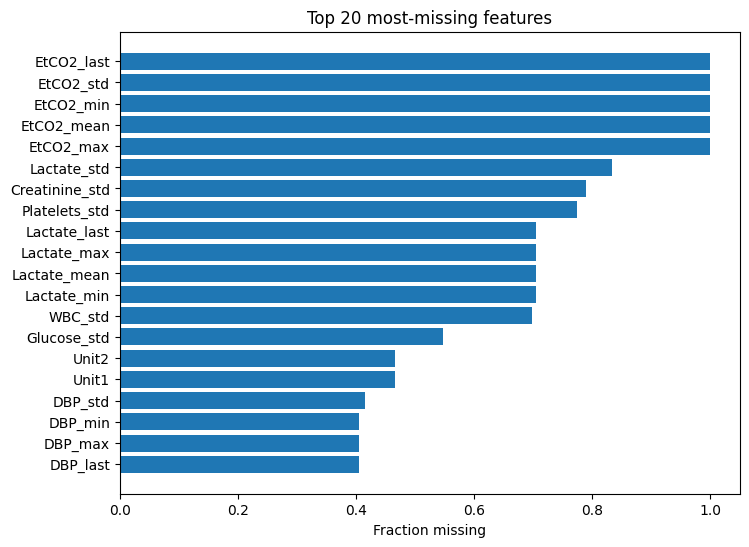

In [9]:
top_missing = missing_summary.head(20).sort_values("missing_fraction")

plt.figure(figsize=(8, 6))
plt.barh(top_missing.index, top_missing["missing_fraction"])
plt.xlabel("Fraction missing")
plt.title("Top 20 most-missing features")
plt.show()

In [10]:
static_missing = data[static_cols].isna().mean().sort_values(ascending=False)

temporal_summary_cols = [c for c in data.columns if c not in ["patient_id", "label"] + static_cols]
temporal_missing = data[temporal_summary_cols].isna().mean().sort_values(ascending=False)

print("Static feature missingness:")
print(static_missing)

print("\nTemporal summary feature missingness (top 20):")
print(temporal_missing.head(20))

Static feature missingness:
Unit1          0.466
Unit2          0.466
Age            0.000
Gender         0.000
HospAdmTime    0.000
dtype: float64

Temporal summary feature missingness (top 20):
EtCO2_min         1.0000
EtCO2_std         1.0000
EtCO2_max         1.0000
EtCO2_mean        1.0000
EtCO2_last        1.0000
Lactate_std       0.8342
Creatinine_std    0.7901
Platelets_std     0.7745
Lactate_mean      0.7042
Lactate_last      0.7042
Lactate_max       0.7042
Lactate_min       0.7042
WBC_std           0.6982
Glucose_std       0.5480
DBP_std           0.4158
DBP_last          0.4056
DBP_min           0.4056
DBP_max           0.4056
DBP_mean          0.4056
WBC_min           0.2420
dtype: float64


In [11]:
MISSING_THRESHOLD = 0.85

feature_cols = [c for c in data.columns if c not in ["patient_id", "label"]]
missing_fraction = data[feature_cols].isna().mean()

kept_features = missing_fraction[missing_fraction <= MISSING_THRESHOLD].index.tolist()
dropped_features = missing_fraction[missing_fraction > MISSING_THRESHOLD].index.tolist()

print("Kept features:", len(kept_features))
print("Dropped features:", len(dropped_features))
print("\nDropped feature examples:")
print(dropped_features[:20])

data = data[["patient_id", "label"] + kept_features].copy()

Kept features: 65
Dropped features: 5

Dropped feature examples:
['EtCO2_mean', 'EtCO2_std', 'EtCO2_min', 'EtCO2_max', 'EtCO2_last']


Total patients: 10000
Sepsis patients: 284 (2.84%)
Non-sepsis patients: 9716 (97.16%)


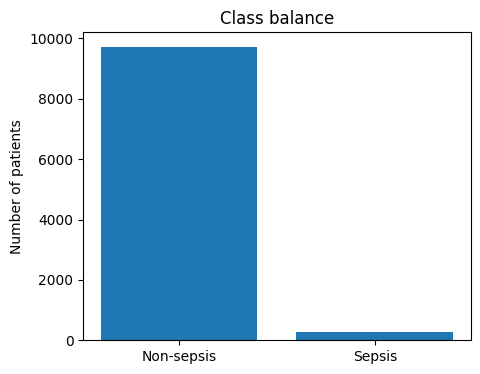

In [12]:
n_total = len(data)
n_positive = data["label"].sum()
n_negative = n_total - n_positive

print(f"Total patients: {n_total}")
print(f"Sepsis patients: {n_positive} ({n_positive / n_total:.2%})")
print(f"Non-sepsis patients: {n_negative} ({n_negative / n_total:.2%})")

# Plot
class_counts = data["label"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(["Non-sepsis", "Sepsis"], [class_counts.get(0, 0), class_counts.get(1, 0)])
plt.ylabel("Number of patients")
plt.title("Class balance")
plt.show()

The dataset is highly imbalanced, with sepsis patients representing only a small fraction of the cohort. Because of this, threshold-dependent metrics such as precision, recall, and F1-score are more informative than accuracy, and threshold analysis is necessary to understand clinically relevant trade-offs.

### Define feature groups

In [13]:
static_features = [col for col in static_cols if col in data.columns]

temporal_features = [
    col for col in data.columns
    if col not in ["patient_id", "label"] + static_features
]

multimodal_features = static_features + temporal_features

print("Static features:", len(static_features))
print("Temporal features:", len(temporal_features))
print("Multimodal features:", len(multimodal_features))

# ---------------------------- Train/test split ---------------------------- #
train_df, test_df = train_test_split(
    data,
    test_size=0.2,
    stratify=data["label"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Static features: 5
Temporal features: 60
Multimodal features: 65
Train shape: (8000, 67)
Test shape: (2000, 67)


### Helpers

In [14]:
# Evaluation helper
def evaluate_model_threshold(name, model, X_train, y_train, X_test, y_test, threshold):
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "model": name,
        "threshold": threshold,
        "AUC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0)
    }

# Pipeline builder
def make_logreg_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

def make_rf_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ])


### Models

In [15]:
thresholds = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]

# Static-only model
X_train_static = train_df[static_features]
X_test_static = test_df[static_features]

# Temporal-only model
X_train_temp = train_df[temporal_features]
X_test_temp = test_df[temporal_features]

# Multimodal model
X_train_multi = train_df[multimodal_features]
X_test_multi = test_df[multimodal_features]

y_train = train_df["label"]
y_test = test_df["label"]

# Threshold loop
results = []

for t in thresholds:
    results.append(
        evaluate_model_threshold(
            "Static_LogReg",
            make_logreg_pipeline(),
            X_train_static, y_train,
            X_test_static, y_test,
            threshold=t
        )
    )

    results.append(
        evaluate_model_threshold(
            "Temporal_LogReg",
            make_logreg_pipeline(),
            X_train_temp, y_train,
            X_test_temp, y_test,
            threshold=t
        )
    )

    results.append(
        evaluate_model_threshold(
            "Multimodal_LogReg",
            make_logreg_pipeline(),
            X_train_multi, y_train,
            X_test_multi, y_test,
            threshold=t
        )
    )

    results.append(
        evaluate_model_threshold(
            "Multimodal_RF",
            make_rf_pipeline(),
            X_train_multi, y_train,
            X_test_multi, y_test,
            threshold=t
        )
    )

results_df = pd.DataFrame(results)
results_df.sort_values(["threshold", "model"])

,model,threshold,AUC,AUPRC,F1,Precision,Recall
2,Multimodal_LogReg,0.1,0.634170,0.049343,0.056094,0.028887,0.964912
3,Multimodal_RF,0.1,0.697628,0.068100,0.112903,0.104478,0.122807
0,Static_LogReg,0.1,0.596080,0.055394,0.055421,0.028500,1.000000
1,Temporal_LogReg,0.1,0.609629,0.043103,0.056940,0.029319,0.982456
6,Multimodal_LogReg,0.2,0.634170,0.049343,0.060680,0.031427,0.877193
7,Multimodal_RF,0.2,0.697628,0.068100,0.033333,0.333333,0.017544
4,Static_LogReg,0.2,0.596080,0.055394,0.055421,0.028500,1.000000
5,Temporal_LogReg,0.2,0.609629,0.043103,0.060000,0.031041,0.894737
10,Multimodal_LogReg,0.3,0.634170,0.049343,0.066504,0.034864,0.719298
11,Multimodal_RF,0.3,0.697628,0.068100,0.000000,0.000000,0.000000


### Compare results

In [16]:
results_df = pd.DataFrame(results)

results_df.sort_values(["model", "threshold"])

pivot = results_df.pivot_table(
    index=["model", "threshold"],
    values=["Precision", "Recall", "F1"]
)

pivot

F1  Precision    Recall
model             threshold                               
Multimodal_LogReg 0.1        0.056094   0.028887  0.964912
                  0.2        0.060680   0.031427  0.877193
                  0.3        0.066504   0.034864  0.719298
                  0.5        0.095726   0.053030  0.491228
                  0.7        0.086207   0.057143  0.175439
                  0.9        0.026667   0.055556  0.017544
Multimodal_RF     0.1        0.112903   0.104478  0.122807
                  0.2        0.033333   0.333333  0.017544
                  0.3        0.000000   0.000000  0.000000
                  0.5        0.000000   0.000000  0.000000
                  0.7        0.000000   0.000000  0.000000
                  0.9        0.000000   0.000000  0.000000
Static_LogReg     0.1        0.055421   0.028500  1.000000
                  0.2        0.055421   0.028500  1.000000
                  0.3        0.055421   0.028500  1.000000
                  0.5        0.070556   0.038235  0.456140
                  0.7        0.074766   0.080000  0.070175
                  0.9        0.032258   0.200000  0.017544
Temporal_LogReg   0.1        0.056940   0.029319  0.982456
                  0.2        0.060000   0.031041  0.894737
                  0.3        0.067557   0.035362  0.754386
                  0.5        0.088816   0.049002  0.473684
                  0.7        0.055814   0.037975  0.105263
                  0.9        0.000000   0.000000  0.000000

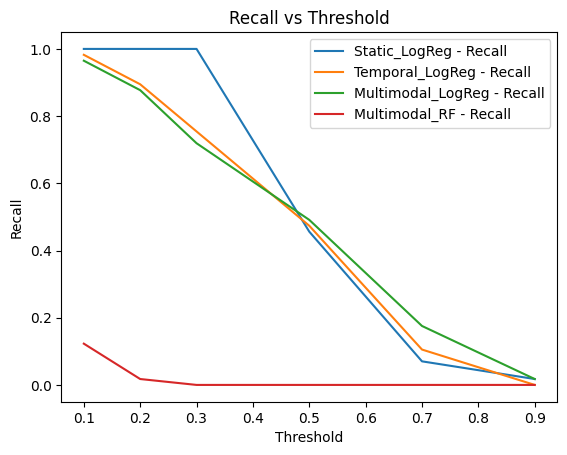

In [17]:
# Plot trade-offs (important)
for model_name in results_df["model"].unique():
    subset = results_df[results_df["model"] == model_name]
    plt.plot(subset["threshold"], subset["Recall"], label=f"{model_name} - Recall")

plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Threshold")
plt.legend()
plt.show()

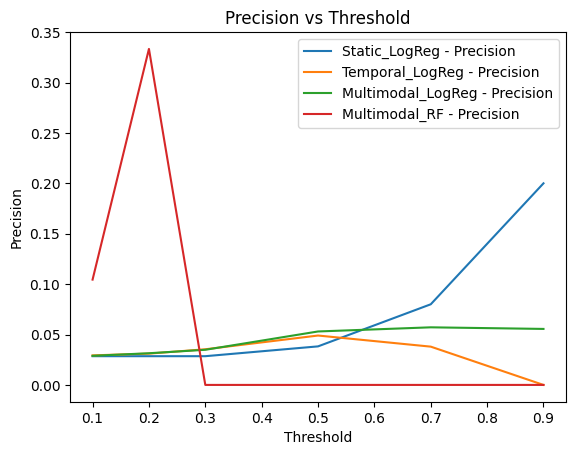

In [18]:
# Plot trade-offs (important)
for model_name in results_df["model"].unique():
    subset = results_df[results_df["model"] == model_name]
    plt.plot(subset["threshold"], subset["Precision"], label=f"{model_name} - Precision")

plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Precision vs Threshold")
plt.legend()
plt.show()

In [19]:
selected_thresholds = [0.2, 0.5, 0.9]
selected_models = ["Temporal_LogReg", "Multimodal_LogReg", "Static_LogReg"]

summary_table = results_df[
    (results_df["threshold"].isin(selected_thresholds)) &
    (results_df["model"].isin(selected_models))
].copy().sort_values(["model", "threshold"])

summary_table

,model,threshold,AUC,AUPRC,F1,Precision,Recall
6,Multimodal_LogReg,0.2,0.634170,0.049343,0.060680,0.031427,0.877193
14,Multimodal_LogReg,0.5,0.634170,0.049343,0.095726,0.053030,0.491228
22,Multimodal_LogReg,0.9,0.634170,0.049343,0.026667,0.055556,0.017544
4,Static_LogReg,0.2,0.596080,0.055394,0.055421,0.028500,1.000000
12,Static_LogReg,0.5,0.596080,0.055394,0.070556,0.038235,0.456140
20,Static_LogReg,0.9,0.596080,0.055394,0.032258,0.200000,0.017544
5,Temporal_LogReg,0.2,0.609629,0.043103,0.060000,0.031041,0.894737
13,Temporal_LogReg,0.5,0.609629,0.043103,0.088816,0.049002,0.473684
21,Temporal_LogReg,0.9,0.609629,0.043103,0.000000,0.000000,0.000000


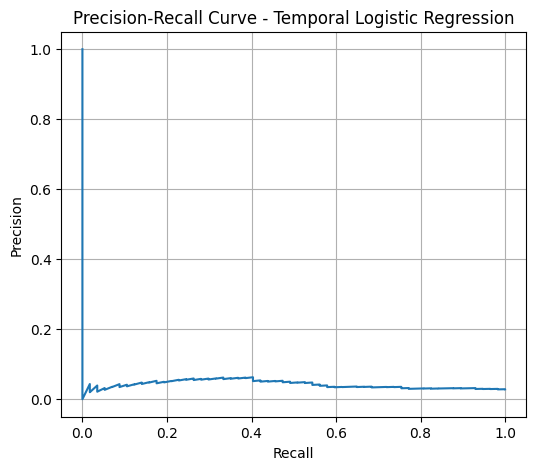

In [20]:
# Select best model

best_model = make_logreg_pipeline()

X_train_best = train_df[temporal_features]
X_test_best = test_df[temporal_features]

y_train = train_df["label"]
y_test = test_df["label"]

best_model.fit(X_train_best, y_train)

from sklearn.metrics import precision_recall_curve

y_prob = best_model.predict_proba(X_test_best)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Temporal Logistic Regression")
plt.grid()
plt.show()

In [21]:
best_f1_table = results_df.loc[
    results_df.groupby("model")["F1"].idxmax()
].sort_values("F1", ascending=False)

best_f1_table

,model,threshold,AUC,AUPRC,F1,Precision,Recall
3,Multimodal_RF,0.1,0.697628,0.068100,0.112903,0.104478,0.122807
14,Multimodal_LogReg,0.5,0.634170,0.049343,0.095726,0.053030,0.491228
13,Temporal_LogReg,0.5,0.609629,0.043103,0.088816,0.049002,0.473684
16,Static_LogReg,0.7,0.596080,0.055394,0.074766,0.080000,0.070175


### Feature importance for Random Forest

In [22]:
rf_for_importance = make_rf_pipeline()

X_train_multi = train_df[multimodal_features]
X_test_multi = test_df[multimodal_features]
y_train = train_df["label"]
y_test = test_df["label"]

rf_for_importance.fit(X_train_multi, y_train)

rf_model = rf_for_importance.named_steps["model"]
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": multimodal_features,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
4,HospAdmTime,0.034437
18,Temp_max,0.029482
35,Resp_mean,0.029073
19,Temp_last,0.028245
5,HR_mean,0.028158
15,Temp_mean,0.027715
11,O2Sat_std,0.025010
9,HR_last,0.024094
37,Resp_min,0.023956
8,HR_max,0.023630


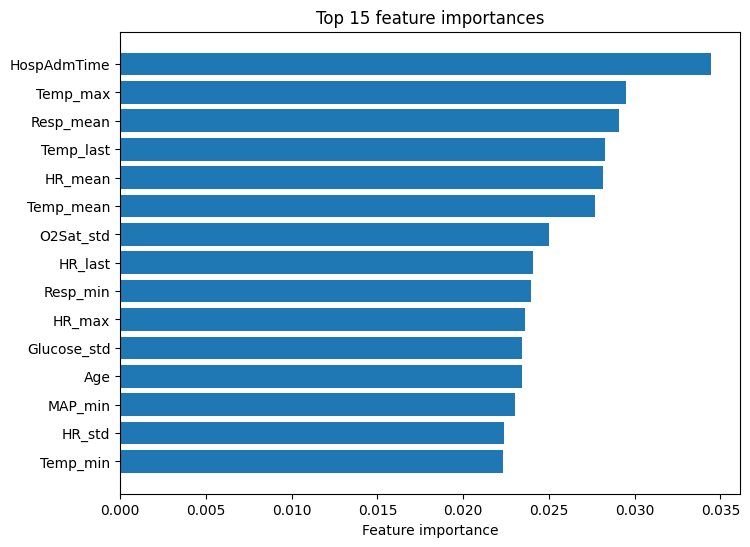

In [23]:
top_n = 15
top_feat = feat_imp.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_feat["feature"], top_feat["importance"])
plt.xlabel("Feature importance")
plt.title("Top 15 feature importances")
plt.show()

In [24]:
import os
os.makedirs("results", exist_ok=True)

results_df.to_csv("results/results_threshold_analysis.csv", index=False)
summary_table.to_csv("results/results_summary.csv", index=False)
best_f1_table.to_csv("results/results_best_f1_per_model.csv", index=False)

## Conclusion

This notebook presented a proof-of-concept pipeline for early sepsis prediction using open ICU time-series data from PhysioNet. A patient-level representation was constructed from the first 12 hours of ICU data by combining static admission variables with summarized temporal physiological measurements.

The analysis showed that:
- the dataset is highly imbalanced, with sepsis patients representing only a small proportion of the cohort;
- missingness is substantial for several variables, but can be handled through selective feature removal and median imputation;
- predictive performance depends strongly on the decision threshold, with lower thresholds improving recall at the expense of precision;
- temporal and multimodal models provide useful early predictive signal, while feature importance analysis identifies clinically meaningful variables.

Overall, this project demonstrates a simple but relevant framework for interpretable modeling of temporal healthcare data. Future work could extend this approach using richer sequence models, calibration, SHAP-based explanations, and broader multimodal biomedical applications, including oncology and longitudinal experimental systems.